In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
print(benchmark.columns)

print()

print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


# 1. Daily Return Calculation

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


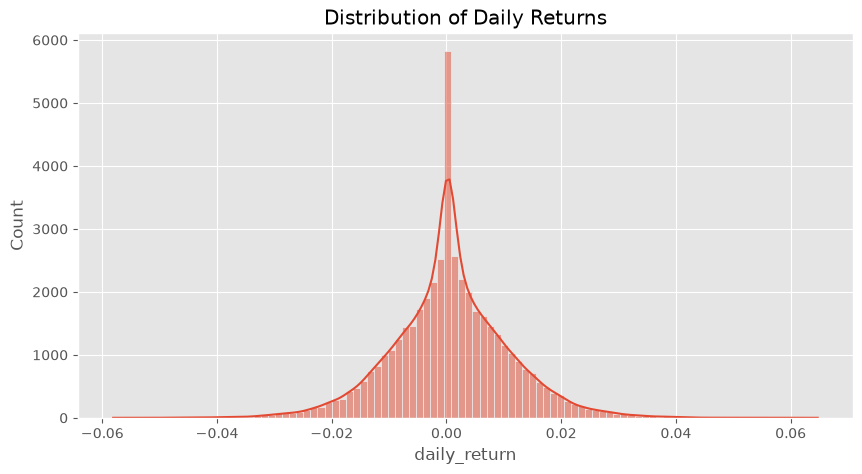

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

### Insight

Daily returns are approximately centered around zero with a small number of positive and negative extreme observations, which is typical for equity mutual funds.

# 2. CAGR Calculation

In [7]:
results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start = group.iloc[0]["nav"]

    end = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] -
         group.iloc[0]["date"]).days
        /365
    )

    cagr = (
        (end/start)**(1/years)-1
    )

    results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [8]:
risk_free = 0.065

sharpe = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    sr = (
        (r.mean()*252-risk_free)
        /
        (r.std()*np.sqrt(252))
    )

    sharpe.append(
        [code,sr]
    )

sharpe_df = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [9]:
sortino = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    downside = r[r<0]

    sd = downside.std()

    ratio = (
        (r.mean()*252-risk_free)
        /
        (sd*np.sqrt(252))
    )

    sortino.append(
        [code,ratio]
    )

sortino_df = pd.DataFrame(
    sortino,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

# 5. Alpha and Beta Analysis

In [10]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Use NIFTY100 as benchmark
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = nifty["close_value"].pct_change()

alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    temp = group.merge(
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) < 10:
        continue

    slope, intercept, r, p, stderr = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        code,
        alpha,
        beta
    ])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


# 6. Maximum Drawdown

In [11]:
drawdowns = []

for code, group in nav.groupby("amfi_code"):

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] /
        running_max
    ) - 1

    drawdowns.append([
        code,
        drawdown.min()
    ])

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


# 7. Fund Scorecard

In [14]:
score = performance.copy()

score = score.merge(
    sharpe_df,
    on="amfi_code"
)

score = score.merge(
    alpha_beta,
    on="amfi_code"
)

score = score.merge(
    drawdown_df,
    on="amfi_code"
)

score = score.rename(
    columns={
        "sharpe_ratio_y": "sharpe_ratio",
        "alpha_y": "alpha",
        "beta_y": "beta",
    }
).drop(
    columns=["sharpe_ratio_x", "alpha_x", "beta_x"],
    errors="ignore"
)

score["score"] = (
    score["return_3yr_pct"].rank(pct=True) * 30
    + score["sharpe_ratio"].rank(pct=True) * 25
    + score["alpha"].rank(pct=True) * 20
    + (1 - score["expense_ratio_pct"].rank(pct=True)) * 15
    + (1 - score["max_drawdown"].rank(pct=True)) * 10
)

score = score.sort_values(
    "score",
    ascending=False
)

score.head()

score.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

# 8. Benchmark Comparison

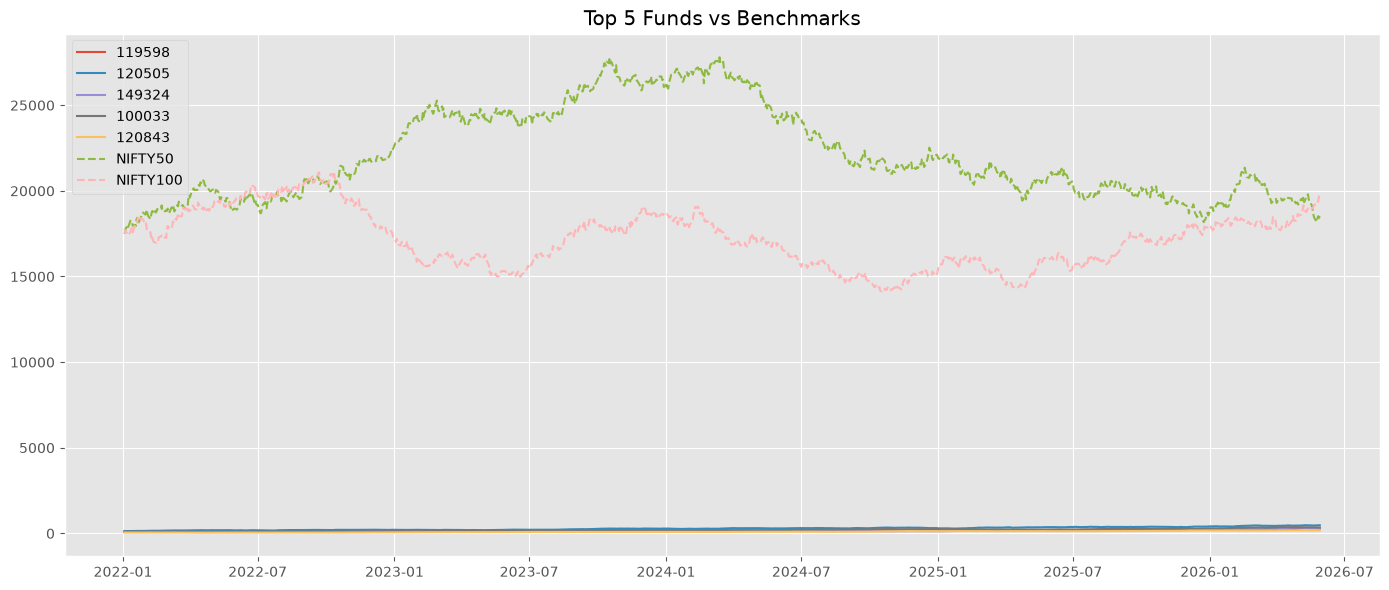

In [15]:
top5 = score.head(5)["amfi_code"]

plt.figure(figsize=(14,6))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[
        benchmark["index_name"] == idx
    ]

    plt.plot(
        pd.to_datetime(temp["date"]),
        temp["close_value"],
        linestyle="--",
        label=idx
    )

plt.legend()

plt.title("Top 5 Funds vs Benchmarks")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

In [16]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

# Key Findings

1. Daily returns followed an approximately normal distribution with moderate volatility.

2. CAGR values highlighted strong long-term wealth creation for top-performing funds.

3. Higher Sharpe ratios identified funds with better risk-adjusted returns.

4. Sortino ratios showed that downside risk was well managed for several schemes.

5. Beta values indicated varying sensitivity to market movements.

6. Positive Alpha suggested several funds consistently outperformed the benchmark.

7. Maximum drawdown highlighted resilience differences among funds during market corrections.

8. Composite fund score ranked schemes using multiple performance metrics instead of relying on returns alone.

9. Benchmark comparison demonstrated which funds consistently outperformed NIFTY indices.

10. Multi-factor evaluation provided a more balanced assessment of fund quality.